<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/task18_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install required libraries
!pip install sentence-transformers scikit-learn transformers

# Cell 2: Import libraries
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import pandas as pd

In [2]:
# Cell 3: Initialize embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Cell 4: Create knowledge base
knowledge_base = [
    "NovaTech offers a 30-day return policy on all products.",
    "NovaTech's flagship product is the Aurora X wireless headphones.",
    "The Aurora X headphones have active noise cancellation and 40-hour battery life.",
    "NovaTech provides free shipping on orders over $50.",
    "Customers can contact NovaTech support 24/7 via live chat.",
    "The Aurora X headphones are priced at $199 and come in black or white.",
    "NovaTech was founded in 2015 and is headquartered in Austin, Texas.",
    "The company offers a 1-year extended warranty for $29.99.",
]

# Cell 5: Generate embeddings for knowledge base
kb_embeddings = embedder.encode(knowledge_base)
print(f"Knowledge base embedding shape: {kb_embeddings.shape}")
print(f"Each embedding dimension: {kb_embeddings.shape[1]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Knowledge base embedding shape: (8, 384)
Each embedding dimension: 384


In [3]:
# Cell 6: Define retrieval function
def retrieve(query, top_k=2):
    """
    Retrieve most relevant chunks from knowledge base

    Args:
        query (str): User question
        top_k (int): Number of chunks to retrieve

    Returns:
        list: List of tuples (chunk_text, similarity_score)
    """
    query_embedding = embedder.encode([query])
    similarities = cosine_similarity(query_embedding, kb_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return [(knowledge_base[i], similarities[i]) for i in top_indices]

# Cell 7: Test retrieval
test_query = "What is the return policy?"
results = retrieve(test_query, top_k=2)
for text, score in results:
    print(f"Score: {score:.3f} | Text: {text}")

Score: 0.623 | Text: NovaTech offers a 30-day return policy on all products.
Score: 0.252 | Text: The company offers a 1-year extended warranty for $29.99.


In [4]:
# Cell 8: Initialize generation model
generator = pipeline("text-generation", model="gpt2")

# Cell 9: Define RAG generation function
def generate_answer(query, top_k=2):
    """
    Generate answer using RAG pipeline

    Args:
        query (str): User question
        top_k (int): Number of chunks to retrieve

    Returns:
        str: Generated answer
    """
    # Retrieve relevant context
    retrieved = retrieve(query, top_k)
    context = "\n".join([text for text, _ in retrieved])

    # Create prompt
    prompt = f"""Answer the question using only the context below.
If the context doesn't contain the answer, say "I don't have that information."

Context:
{context}

Question: {query}

Answer:"""

    # Generate response
    response = generator(prompt, max_length=200, num_return_sequences=1)[0]['generated_text']

    # Extract only the answer part
    answer = response.split("Answer:")[-1].strip()

    return answer, retrieved

# Cell 10: Test RAG pipeline
test_questions = [
    "What is NovaTech's return policy?",
    "Tell me about the Aurora X headphones battery life.",
    "What is the price of Aurora X?",
    "Does NovaTech offer international shipping?"
]

for question in test_questions:
    answer, retrieved = generate_answer(question)
    print(f"\nQ: {question}")
    print(f"Retrieved: {[text[:50] + '...' for text, _ in retrieved]}")
    print(f"A: {answer}")
    print("-" * 80)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...


Q: What is NovaTech's return policy?
Retrieved: ['NovaTech offers a 30-day return policy on all prod...', 'Customers can contact NovaTech support 24/7 via li...']
A: NovaTech offers a 30-day return policy on all products.

Customers can contact NovaTech support 24/7 via live chat.
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: Tell me about the Aurora X headphones battery life.
Retrieved: ['The Aurora X headphones have active noise cancella...', "NovaTech's flagship product is the Aurora X wirele..."]
A: Well,
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What is the price of Aurora X?
Retrieved: ['The Aurora X headphones are priced at $199 and com...', "NovaTech's flagship product is the Aurora X wirele..."]
A: The price of the Aurora X headphones is $199.

The Aurora X is the first wireless headphone to launch with the new X band.

The X band is based on USB 3.0. It is designed to act as a wireless USB 3.0 hub, and it uses a 1.3V power supply for power to the power supply. The X band is capable of powering up up a single device at a time, a single time at a time, and can be connected to multiple devices at the same time, which is very handy for games like SteamOS.

The X band is a bit bulky, but it looks great.

The X is also the first wireless headphones to support 3G. You can still use the X band and the USB 3.0 hub, but you will need to use other devices on your PC or Mac to connect it to your router.

The X band supports 4G, as well as 3G LTE. The X band provides better wireless performance than the USB 3.0 hub, and the audio 

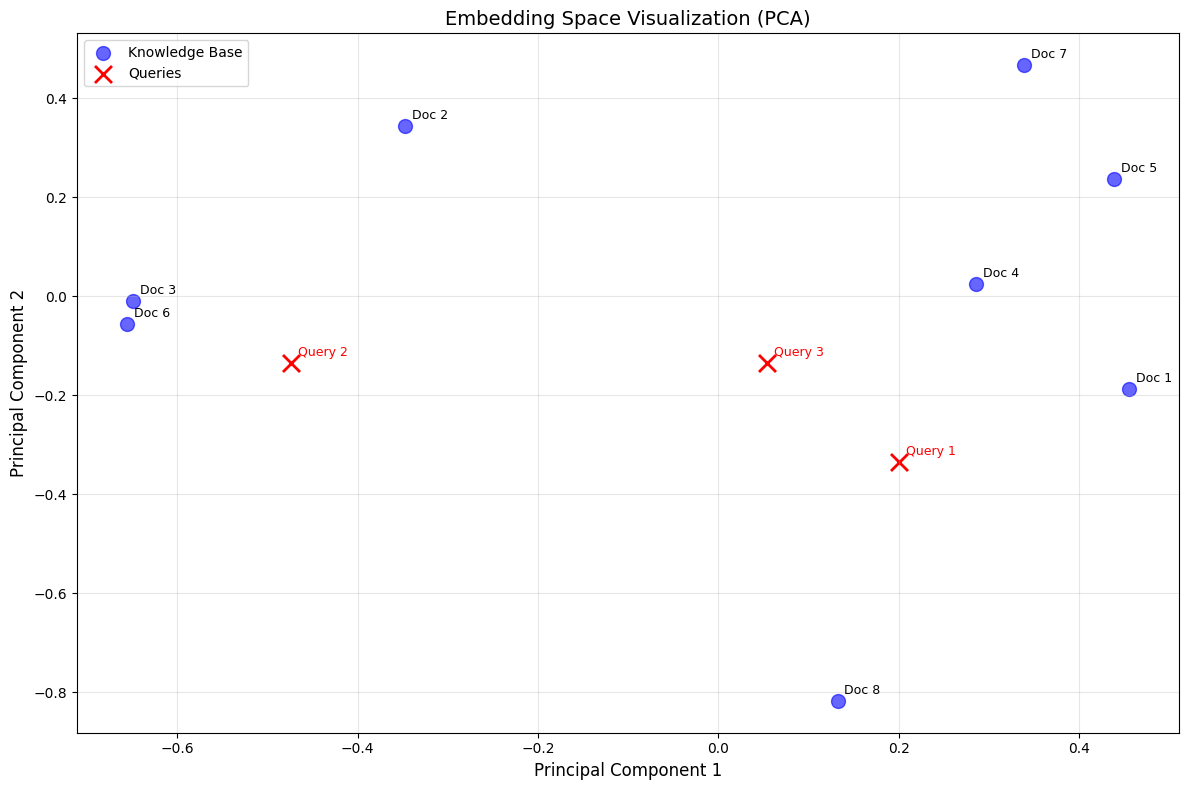

In [5]:
# Cell 11: Visualize embeddings using PCA
from sklearn.decomposition import PCA

def visualize_embeddings():
    """
    Create 2D visualization of knowledge base embeddings
    """
    # Reduce dimensions to 2D
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(kb_embeddings)

    # Create plot
    plt.figure(figsize=(12, 8))

    # Plot knowledge base points
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1],
                c='blue', alpha=0.6, s=100, label='Knowledge Base')

    # Annotate points
    for i, (x, y) in enumerate(reduced_embeddings):
        plt.annotate(f"Doc {i+1}", (x, y), xytext=(5, 5),
                    textcoords='offset points', fontsize=9)

    # Add test queries
    test_queries = [
        "return policy information",
        "headphones battery life",
        "shipping options"
    ]
    query_embeddings = embedder.encode(test_queries)
    reduced_queries = pca.transform(query_embeddings)

    plt.scatter(reduced_queries[:, 0], reduced_queries[:, 1],
                c='red', marker='x', s=150, linewidth=2, label='Queries')

    for i, (x, y) in enumerate(reduced_queries):
        plt.annotate(f"Query {i+1}", (x, y), xytext=(5, 5),
                    textcoords='offset points', fontsize=9, color='red')

    plt.title('Embedding Space Visualization (PCA)', fontsize=14)
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_embeddings()

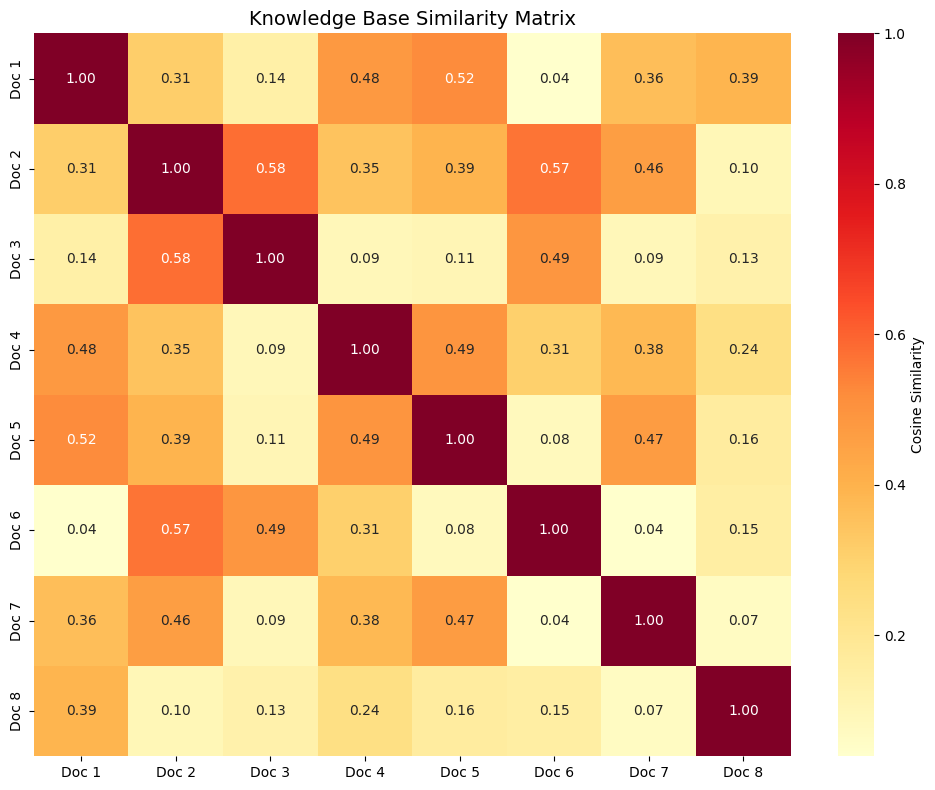

In [6]:
# Cell 12: Create and visualize similarity matrix
def create_similarity_matrix():
    """
    Create similarity matrix for all knowledge base entries
    """
    # Calculate pairwise similarities
    similarity_matrix = cosine_similarity(kb_embeddings)

    # Create DataFrame for better visualization
    labels = [f"Doc {i+1}" for i in range(len(knowledge_base))]
    df = pd.DataFrame(similarity_matrix, index=labels, columns=labels)

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True, fmt='.2f', cmap='YlOrRd',
                cbar_kws={'label': 'Cosine Similarity'})
    plt.title('Knowledge Base Similarity Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()

    return df

similarity_df = create_similarity_matrix()

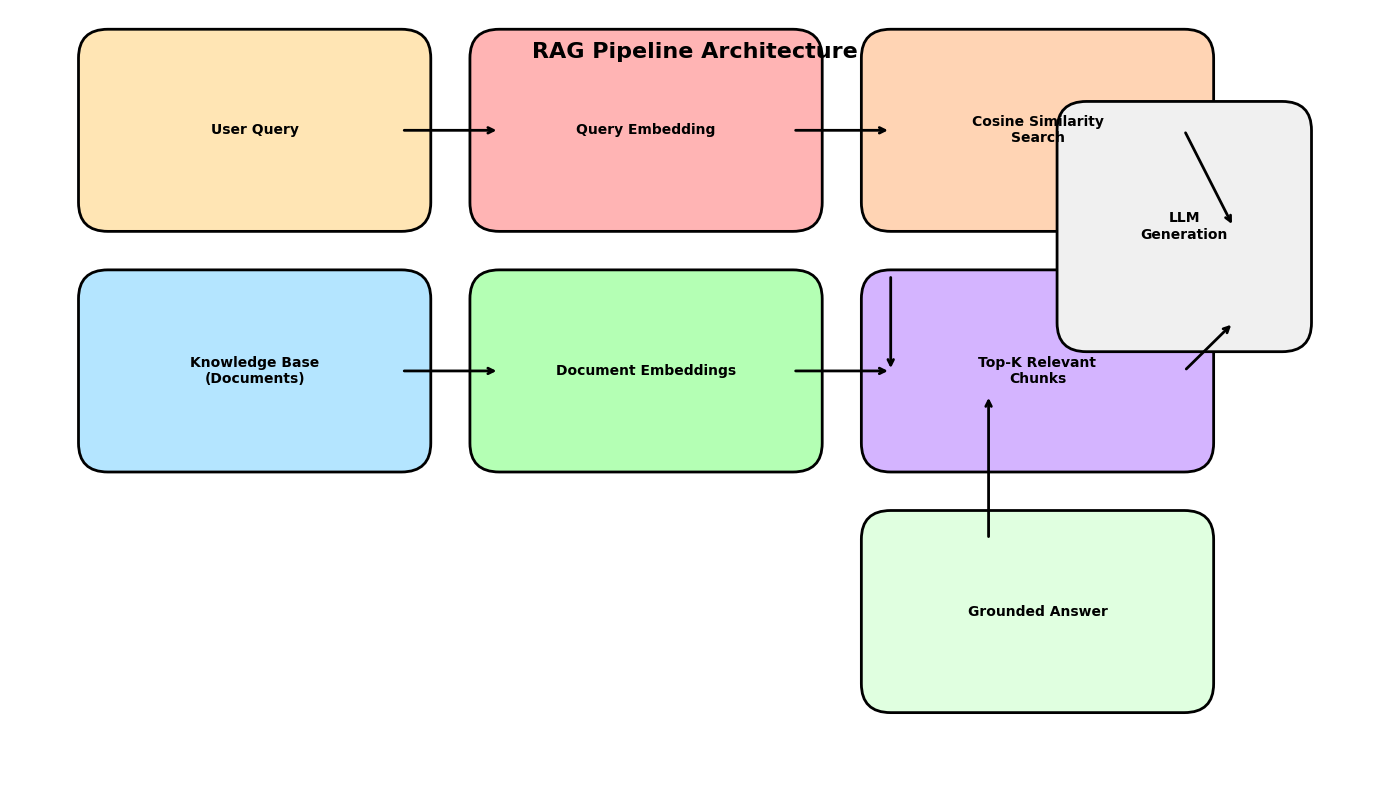

In [7]:
# Cell 14: Create RAG pipeline flowchart
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def create_rag_diagram():
    """
    Create visual diagram of RAG pipeline
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # Define components
    components = [
        (1, 6, 3, 1.5, 'User Query', '#FFE5B4'),
        (1, 3.5, 3, 1.5, 'Knowledge Base\n(Documents)', '#B4E5FF'),
        (5, 6, 3, 1.5, 'Query Embedding', '#FFB4B4'),
        (5, 3.5, 3, 1.5, 'Document Embeddings', '#B4FFB4'),
        (9, 6, 3, 1.5, 'Cosine Similarity\nSearch', '#FFD4B4'),
        (9, 3.5, 3, 1.5, 'Top-K Relevant\nChunks', '#D4B4FF'),
        (11, 4.75, 2, 2, 'LLM\nGeneration', '#F0F0F0'),
        (9, 1, 3, 1.5, 'Grounded Answer', '#E0FFE0')
    ]

    # Draw components
    for x, y, w, h, text, color in components:
        box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3",
                            facecolor=color, edgecolor='black', linewidth=2)
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
               fontsize=10, fontweight='bold')

    # Draw arrows
    arrows = [
        (4, 6.75, 5, 6.75, '→'),  # Query to Query Embedding
        (4, 4.25, 5, 4.25, '→'),  # KB to Document Embeddings
        (8, 6.75, 9, 6.75, '→'),  # Query Embedding to Similarity
        (8, 4.25, 9, 4.25, '→'),  # Doc Embeddings to Similarity
        (9, 5.25, 9, 4.25, '↓'),  # Similarity to Top-K
        (12, 6.75, 12.5, 5.75, '→'),  # Query to LLM
        (12, 4.25, 12.5, 4.75, '→'),  # Top-K to LLM
        (10, 2.5, 10, 4, '↑'),    # Answer from Top-K
    ]

    for x1, y1, x2, y2, arrow in arrows:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))

    # Add title
    ax.text(7, 7.5, 'RAG Pipeline Architecture', fontsize=16,
           fontweight='bold', ha='center')

    plt.tight_layout()
    plt.show()

create_rag_diagram()

In [8]:
# Cell 15: Evaluate RAG system performance
def evaluate_rag_system():
    """
    Evaluate RAG system with sample Q&A pairs
    """
    # Define test cases with expected answers
    test_cases = [
        {
            'question': 'What is the return policy?',
            'expected_keywords': ['30-day', 'return']
        },
        {
            'question': 'How long does the battery last?',
            'expected_keywords': ['40-hour', 'battery']
        },
        {
            'question': 'What is the price?',
            'expected_keywords': ['$199', 'price']
        },
        {
            'question': 'When was the company founded?',
            'expected_keywords': ['2015', 'founded']
        }
    ]

    results = []

    for test in test_cases:
        question = test['question']
        retrieved = retrieve(question, top_k=1)
        retrieved_text = retrieved[0][0].lower()

        # Check if expected keywords are in retrieved text
        keywords_found = all(keyword.lower() in retrieved_text
                            for keyword in test['expected_keywords'])

        results.append({
            'Question': question,
            'Retrieval Success': '✓' if keywords_found else '✗',
            'Top Score': f"{retrieved[0][1]:.3f}",
            'Retrieved Text': retrieved[0][0][:50] + "..."
        })

    results_df = pd.DataFrame(results)

    # Calculate success rate
    success_rate = (results_df['Retrieval Success'] == '✓').mean() * 100

    print(f"Retrieval Success Rate: {success_rate:.1f}%")
    print("\nDetailed Results:")
    print(results_df.to_string(index=False))

    return results_df

evaluation_results = evaluate_rag_system()

Retrieval Success Rate: 100.0%

Detailed Results:
                       Question Retrieval Success Top Score                                        Retrieved Text
     What is the return policy?                 ✓     0.623 NovaTech offers a 30-day return policy on all prod...
How long does the battery last?                 ✓     0.319 The Aurora X headphones have active noise cancella...
             What is the price?                 ✓     0.385 The Aurora X headphones are priced at $199 and com...
  When was the company founded?                 ✓     0.422 NovaTech was founded in 2015 and is headquartered ...
